<a href="https://colab.research.google.com/github/linda-r-wu/econ5200-lab02-deflation/blob/main/lab_ch02_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Measurement & Indexes — Diagnostic Lab

**ECON 5200: Causal Machine Learning & Applied Analytics**

This lab uses a **diagnosis-first** format. You will:
1. Find and fix 4 bugs in a broken deflation pipeline
2. Compare CPI-U vs. Chained CPI (C-CPI-U) to quantify substitution bias
3. Build a multi-metric KPI dashboard demonstrating Goodhart's Law
4. Write a verification module (`deflation_utils.py`)

**Time estimate:** 45-60 minutes (20 minutes if you already know FRED and pandas well)

**Prerequisites:** Chapter 2 reading, including [5200-DEPTH] sections on index number theory and KPI taxonomy

**AI in the manual parts:** you may ask Colab to *explain* an error or a line of code (click **Explain error**, or select a line and ask Gemini to explain it). Do not ask it to write or fix code, and turn off AI code completion while you work on those parts. AI-assisted coding is allowed only where this lab says so.

## Setup

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def load_fred(series_id, observation_start="1947-01-01"):
#     """Return one FRED series as a pandas Series indexed by date.

#     Uses FRED's public CSV endpoint, which needs NO API key and no account.
#     Every graded part of this lab runs through this function, so nothing here
#     is blocked on a credential.

#     FRED has renamed the value column before now, so we set both column names
#     positionally rather than trusting the header.
#     """
    url = (
        "https://fred.stlouisfed.org/graph/fredgraph.csv?"
        f"id={series_id}&cosd={observation_start}"
    )
    frame = pd.read_csv(url)
    frame.columns = ["date", series_id]
    frame["date"] = pd.to_datetime(frame["date"])
    frame[series_id] = pd.to_numeric(frame[series_id], errors="coerce")
    return frame.set_index("date")[series_id].dropna()
# OPTIONAL — the fredapi package does the same job behind a free API key, and
# adds search, metadata and vintages. Nothing in this lab needs it:
#
#!pip install fredapi -q
#from fredapi import Fred
#from google.colab import userdata
#fred = Fred(api_key=userdata.get('FRED_API_KEY'))
#fred.get_series("CPIAUCSL", observation_start="1964-01-01")

# Get a key at https://fredaccount.stlouisfed.org/apikeys if you want it.
# NEVER commit a real key to a public repository.

print("Setup complete! (no API key needed)")

Setup complete! (no API key needed)


<!-- 5200-onramp -->
## Part 0: Build It First (GUIDED — 15 min)

Part 4 of this lab asks you to write `deflation_utils.py` — a **module**, a
file of your own that other code can import. That is the professional
deliverable, and it is a real step up from writing cells. This part builds you
up to it.

**This lab's slice of the floor:** functions — `def`, parameters, default
arguments, docstrings, `return`, and raising an error deliberately — plus the
two ways a notebook turns a cell into an importable `.py` file.

*(If you have not done Lab 1's Part 0, do it first: it covers f-strings, the
DataFrame, and boolean masks, all of which are assumed here.)*

In [43]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0a: writing a function
# -----------------------------------------------------------
import pandas as pd
import numpy as np

# A FUNCTION is a named, reusable block. `def` starts it, the indented lines
# are its body, and `return` hands a value back to whoever called it.

def real_rate(nominal, inflation_pct):
    """Return the approximate real interest rate (the Fisher approximation).

    Parameters
    ----------
    nominal : float
        Nominal rate, in percent (5.0 means 5%).
    inflation_pct : float
        Inflation rate, in percent.

    Returns
    -------
    float
    """
    return nominal - inflation_pct

print(f"US:     {real_rate(5.25, 3.10):.2f}%")
print(f"Brazil: {real_rate(10.75, 4.50):.2f}%")

# The triple-quoted string is a DOCSTRING -- documentation, not a comment.
# help() prints it, graders read it, and every function in the modules you
# write this term needs one.
help(real_rate)

# DEFAULT ARGUMENTS make a parameter optional.
def compound(start, rate=0.02, years=5):
    """Compound `start` at `rate` for `years`. Rate and years are optional."""
    return start * (1 + rate) ** years

print(f"\nDefaults:            {compound(100):.2f}")
print(f"Override the rate:   {compound(100, rate=0.05):.2f}")
print(f"Override both:       {compound(100, 0.05, 10):.2f}")

# A function with NO return hands back None. That is a real value, and
# "AttributeError: 'NoneType' object has no attribute ..." almost always means
# you used the result of a function that forgot to return anything.
def just_prints(x):
    print(f"  (printed {x}, returned nothing)")

print("\nWhat did just_prints give back?", just_prints(3))

US:     2.15%
Brazil: 6.25%
Help on function real_rate in module __main__:

real_rate(nominal, inflation_pct)
    Return the approximate real interest rate (the Fisher approximation).

    Parameters
    ----------
    nominal : float
        Nominal rate, in percent (5.0 means 5%).
    inflation_pct : float
        Inflation rate, in percent.

    Returns
    -------
    float


Defaults:            110.41
Override the rate:   127.63
Override both:       162.89
  (printed 3, returned nothing)

What did just_prints give back? None


In [44]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0b: BUILD IT — a correct deflate(), and a deliberate error
# -----------------------------------------------------------
# This is the function Part 1 will show you with a bug in it, and the one you
# will ship as a module in Part 4. Build the correct version now.
#
#     Real value = (Nominal / CPI) * CPI in the base year
#
# Both halves must be in the SAME units and aligned on the SAME dates. The
# classic error is mixing an annual average with a monthly reading, or
# dividing by the base CPI instead of multiplying by it.

# A small CPI series, so this part needs no API key.
demo_dates = pd.date_range("2018-01-01", periods=84, freq="MS")
demo_cpi = pd.Series(100 * (1.0025 ** np.arange(84)), index=demo_dates, name="cpi")
demo_nominal = pd.Series(20 + 0.05 * np.arange(84), index=demo_dates, name="wage")


def deflate(nominal, cpi, base_year=2020):
    """Convert a nominal series to constant base_year dollars.

    `nominal` and `cpi` are PARAMETERS -- names that exist only inside this
    function. That is why they can be short and generic here while the series
    outside are called demo_nominal and demo_cpi.

    Raising on a missing base year is deliberate: returning all-NaN instead
    would let a silent unit error travel downstream into a published number.
    """
    base = cpi.loc[cpi.index.year == base_year]
    if len(base) == 0:
        raise ValueError(f"base_year {base_year} not present in the CPI index")
    return (nominal / cpi) * base.mean()


demo_real = deflate(demo_nominal, demo_cpi, base_year=2020)
print(f"base CPI (2020 mean): {demo_cpi[demo_cpi.index.year == 2020].mean():.2f}")
print(f"first {demo_dates[0].date()}: nominal ${demo_nominal.iloc[0]:.2f} -> real ${demo_real.iloc[0]:.2f}")
print(f"last  {demo_dates[-1].date()}: nominal ${demo_nominal.iloc[-1]:.2f} -> real ${demo_real.iloc[-1]:.2f}")
print(f"\nnominal growth: {(demo_nominal.iloc[-1] / demo_nominal.iloc[0] - 1):.1%}")
print(f"real growth:    {(demo_real.iloc[-1] / demo_real.iloc[0] - 1):.1%}")

# The guard clause, doing its job.
try:
    deflate(demo_nominal, demo_cpi, base_year=1970)
except ValueError as e:
    print(f"\ndeflate(..., base_year=1970) -> ValueError: {e}")

base CPI (2020 mean): 107.65
first 2018-01-01: nominal $20.00 -> real $21.53
last  2024-12-01: nominal $24.15 -> real $21.13

nominal growth: 20.8%
real growth:    -1.9%

deflate(..., base_year=1970) -> ValueError: base_year 1970 not present in the CPI index


### How a notebook makes a real file

Part 4 asks for `deflation_utils.py`. There are two routes and this course uses
both, so recognise each:

**Route 1 — a string, then write it.** What Part 4 of *this* lab does:

```python
module_code = '''
"""Deflation utilities."""
import pandas as pd

def deflate_series(nominal, cpi, base_year=2020):
    ...
'''
with open("deflation_utils.py", "w") as f:
    f.write(module_code.strip())
```

**Route 2 — the `%%writefile` magic.** What Labs 3, 4 and 5 do. A cell whose
*first line* is `%%writefile eda_utils.py` writes the rest of that cell to disk
instead of running it.

Either way the next cell can `import deflation_utils` like any other library.
Two consequences worth knowing before you hit them:

- The file gets **only what is in that cell**. Imports the functions need must
  be written inside it — the notebook's earlier `import pandas as pd` does not
  travel into the file.
- Python caches imported modules. Writing the file again after an edit does not
  change the already-imported version; you need `importlib.reload(module)`, or
  *Restart session*. That is why Part 4 calls `importlib.reload` right after
  the import.

### Now diagnose

You have a correct `deflate()` and its output on screen. Part 1's version
computes something subtly different. Run it, compare the *numbers* against
what you just produced, and only then go looking for the line.

---

## Part 1: Find and Fix the Bugs (DIAGNOSTIC — 15 min)

The following code attempts to deflate nominal wages using CPI data from FRED. It contains **4 bugs** — common errors that even experienced analysts make. Your job: find each bug, explain why it's wrong, and fix it.

**Hint:** The bugs are related to:
- Base period selection
- Date alignment between the two series
- Missing data handling
- The units the output is actually in

Compare the output against the `deflate()` you built in Step 0b before you
read the function line by line.

In [45]:
# -----------------------------------------------------------
# BROKEN CODE — Find and fix the 4 bugs
# -----------------------------------------------------------

def deflate_series_broken(nominal, cpi, base_year=2020):
    """
    Convert nominal series to real values. Contains 4 bugs.
    """
    base_cpi = cpi.loc[f"{base_year}-01-01"]

    real = (nominal / cpi) * base_cpi

    real = nominal / cpi * 100

    return real

# Pull data
wages = load_fred("AHETPI", observation_start="1964-01-01")
cpi_data = load_fred("CPIAUCSL", observation_start="1964-01-01")

result = deflate_series_broken(wages, cpi_data, base_year=2020)

print(f"Result range: {result.min():.2f} to {result.max():.2f}")
print(f"Rows returned: {len(result)}   of which NaN: {result.isna().sum()}")
print(f"Wage months: {len(wages)}   CPI months: {len(cpi_data)}")
print("\n(If these numbers look wrong, you've identified a bug!)")

Result range: 7.62 to 9.82
Rows returned: 752   of which NaN: 1
Wage months: 752   CPI months: 751

(If these numbers look wrong, you've identified a bug!)


### Your Fixes

For each bug, explain:
1. **What's wrong** (1 sentence)
2. **Why it matters** (what does the error do to the output?)
3. **The fix** (show the corrected code)

**bug #1 base period:**

(a) base_cpi = cpi.loc[f"{base_year}-01-01"] only uses january's cpi and not the average of the whole base year.

(b) this matters because wages are stated in 202 dollars which could result in the wrong real wage level.

(c) fix: base = cpi.loc[cpi.index.year == base_year]

real = (nominal / cpi) * base.mean()

**bug #2 date:**

(a) the wage and cpi are not restricted to the same dates that they share.

(b) this matters because wages have to be adjusted using the cpi from that same month of the comparisons are unmatched.

(c) fix: date = nominal.index.intersection(cpi.index)

nominal = nominal.loc[date]

cpi = cpi.loc[date]

**bug #3 NaN:**

(a) leaving NaN values in when a wage or cpi observation is missing.

(b) this matters because the rows with NaN cant be used as real wage values and can cause the row number to be inflated.

(c) fix: return real.dropna()

**bug #4 unit:**

(a) real = nominal / cpi * 100 overwrites the real variable in the line right above it using the base year cpi.

(b) this matters because the output is now not measured in 2020 dollars anymore and is not correctly deflated.

(c) fix: real = (nominal / cpi) * base.mean()

In [46]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Write the corrected function
# -----------------------------------------------------------

def deflate_series_fixed(nominal, cpi, base_year=2020):
    """Convert a nominal time series to constant base_year dollars.

    Returns a Series with no missing values, indexed by the dates on which
    BOTH inputs are observed.
    """
    # YOUR CODE HERE — one fix for every bug you documented above

    base = cpi.loc[cpi.index.year == base_year]
    if len(base) == 0:
      raise ValueError(f"base_year {base_year} not present in the CPI Index")

    date = nominal.index.intersection(cpi.index)
    nominal = nominal.loc[date]
    cpi = cpi.loc[date]

    real = (nominal / cpi) * base.mean()

    return real.dropna()


wages_real = deflate_series_fixed(wages, cpi_data, base_year=2020)
print(f"Real wage range: ${wages_real.min():.2f} to ${wages_real.max():.2f} (2020 $)")
print(f"Real wage in Jan 1973: ${wages_real.loc['1973-01-01']:.2f}")
print(f"Real wage latest ({wages_real.index[-1]:%b %Y}): ${wages_real.iloc[-1]:.2f}")

Real wage range: $19.71 to $25.42 (2020 $)
Real wage in Jan 1973: $24.43
Real wage latest (Aug 2026): $25.20


### Verification Checkpoint

Measured against live FRED (FRED revises, so the second decimal can move):

| | 2020 dollars |
|---|---|
| Jan 1973 | **\$24.43** |
| Latest month | about **\$25.20** |
| Series minimum | \$19.71 (1995) |
| Series maximum | **\$25.42, April 2020** — a composition effect, not a raise |

Before 2000 the peak is January 1973; the all-time maximum is April 2020.

The broken function's 7.62 to 9.82 is not "index units". Dividing by the CPI
and multiplying by 100 expresses wages in **1982–84 dollars**, the CPI's own
reference period, while the code claims 2020 dollars. The number is a real
wage; it is labelled with the wrong year.

Then run the check below. It tests the arithmetic rather than a hard-coded
number, so it keeps working as FRED revises.

In [47]:
# -----------------------------------------------------------
# CHECK — Run as-is after your fix
# -----------------------------------------------------------

def check_deflated(real, nominal, cpi, base_year):
    """Raise AssertionError unless `real` is `nominal` in base_year dollars."""
    assert real is not None, "Got None: the function has no return statement yet."
    n_nan = int(real.isna().sum())
    assert n_nan == 0, f"{n_nan} NaN row(s) in the result."
    rows = real.index.intersection(nominal.index).intersection(cpi.index)
    assert len(rows) == len(real), (
        f"{len(real) - len(rows)} row(s) fall on dates missing from the wage or CPI series.")
    implied_base = real[rows] / nominal[rows] * cpi[rows]
    target = cpi[cpi.index.year == base_year].mean()
    assert np.allclose(implied_base, target, rtol=1e-6), (
        f"The result is scaled to a CPI of {implied_base.median():.2f}; "
        f"base_year={base_year} requires {target:.2f}.")
    return True


check_deflated(wages_real, wages, cpi_data, base_year=2020)
check_deflated(deflate_series_fixed(wages, cpi_data, base_year=2017),
               wages, cpi_data, base_year=2017)
print("Part 1 checks passed: no NaN, aligned dates, and the base_year argument is honoured.")

Part 1 checks passed: no NaN, aligned dates, and the base_year argument is honoured.


## Part 2: CPI-U vs. Chained CPI — Quantifying Substitution Bias (EXTEND — 15 min)

The chapter discussed how the Laspeyres CPI overstates inflation due to substitution bias. The BLS publishes the Chained CPI (C-CPI-U, FRED series SUUR0000SA0) as a partial correction. Let's quantify the gap.

**Compare like with like.** C-CPI-U is published **not seasonally adjusted**,
with **December 1999 = 100**. The CPI-U you used in Part 1 (`CPIAUCSL`) is
seasonally adjusted, so this part pulls the unadjusted CPI-U, `CPIAUCNS`, from
the same month. Mixing the two makes the end-point gap swing by more than a
full index point depending on which month the data happens to end in.

One more property of the series: the last 10–12 months of C-CPI-U are
**preliminary** and are revised as expenditure data arrive, so the most recent
decimal of any gap you compute is provisional.

In [48]:
# -----------------------------------------------------------
# Pull both CPI variants, not seasonally adjusted, from Dec 1999
# -----------------------------------------------------------
cpi_u = load_fred("CPIAUCNS", observation_start="1999-12-01")
cpi_u.name = "CPI-U"

# C-CPI-U (Chained CPI) — FRED series SUUR0000SA0
try:
    cpi_c = load_fred("SUUR0000SA0", observation_start="1999-12-01")
    cpi_c.name = "C-CPI-U"
    print(f"CPI-U observations: {len(cpi_u)}")
    print(f"C-CPI-U observations: {len(cpi_c)}")
except Exception as e:
    print(f"C-CPI-U not available: {e}")
    print("Using synthetic approximation instead.")
    # Approximate: C-CPI-U compounds about 0.27 pp/year slower than CPI-U
    cpi_c = cpi_u / 1.0027 ** (np.arange(len(cpi_u)) / 12)
    cpi_c.name = "C-CPI-U (approx)"

CPI-U observations: 320
C-CPI-U observations: 320


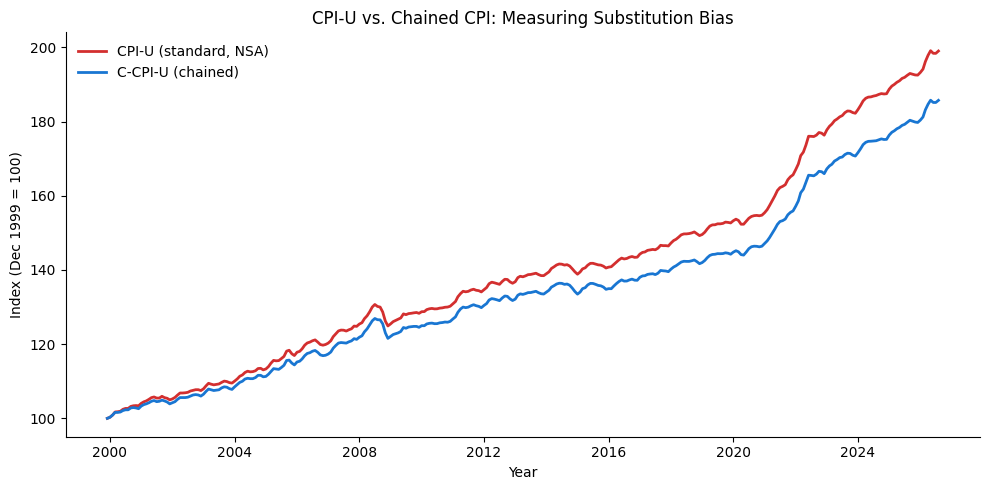

Cumulative gap over 26.7 years: 13.3 index points
That is 0.50 index points per year.

CPI-U:   2.61% per year
C-CPI-U: 2.35% per year
Upper-level substitution bias: 0.27 pp per year


In [49]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Put the gap in the right units
# -----------------------------------------------------------

# GUIDED: normalise both series to 100 in December 1999, and plot
combined = pd.DataFrame({"CPI-U": cpi_u, "C-CPI-U": cpi_c}).dropna()
combined_norm = combined / combined.iloc[0] * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(combined_norm.index, combined_norm["CPI-U"],
        label="CPI-U (standard, NSA)", color="#D32F2F", linewidth=2)
ax.plot(combined_norm.index, combined_norm["C-CPI-U"],
        label="C-CPI-U (chained)", color="#1976D2", linewidth=2)
ax.set_xlabel("Year")
ax.set_ylabel("Index (Dec 1999 = 100)")
ax.set_title("CPI-U vs. Chained CPI: Measuring Substitution Bias")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

years = (combined_norm.index[-1] - combined_norm.index[0]).days / 365.25
gap_points = combined_norm["CPI-U"].iloc[-1] - combined_norm["C-CPI-U"].iloc[-1]
print(f"Cumulative gap over {years:.1f} years: {gap_points:.1f} index points")
print(f"That is {gap_points / years:.2f} index points per year.")

# YOUR TASK: the Boskin Commission, the BLS and the chapter all state
# substitution bias in PERCENTAGE POINTS OF INFLATION PER YEAR. Index points
# per year is not that quantity. Compute the average annual inflation rate of
# each index over `years`, in percent, and take the difference.
cpi_u_rate = (combined_norm["CPI-U"].iloc[-1]/100)**(1 / years) * 100 - 100      # CPI-U average annual inflation, percent per year
cpi_c_rate = (combined_norm["C-CPI-U"].iloc[-1]/100)**(1 / years) * 100 - 100      # C-CPI-U average annual inflation, percent per year
annual_gap_pp = cpi_u_rate - cpi_c_rate

print(f"\nCPI-U:   {cpi_u_rate:.2f}% per year")
print(f"C-CPI-U: {cpi_c_rate:.2f}% per year")
print(f"Upper-level substitution bias: {annual_gap_pp:.2f} pp per year")

In [50]:
# -----------------------------------------------------------
# CHECK — Run as-is
# -----------------------------------------------------------
for label, rate in [("CPI-U", cpi_u_rate), ("C-CPI-U", cpi_c_rate)]:
    end = combined_norm[label].iloc[-1]
    # Accept either convention: annual compounding or a continuous (log) rate.
    annual = 100 * (1 + rate / 100) ** years
    continuous = 100 * np.exp(rate / 100 * years)
    assert min(abs(annual - end), abs(continuous - end)) < 0.5, (
        f"{label}: {rate:.3f}% a year for {years:.1f} years does not take the "
        f"index from 100 to {end:.1f}. Check the units: percent, per year.")
print(f"Part 2 check passed: {annual_gap_pp:.2f} pp per year.")

Part 2 check passed: 0.27 pp per year.


### Interpretation Question

**Q1:** The Boskin Commission (1996) put total substitution bias at about
0.4 pp per year: **0.15 pp upper-level** (substitution *between* item
categories) and **0.25 pp lower-level** (substitution *within* a category).
Since January 1999 the CPI-U itself uses a geometric mean for most lower-level
indexes. Which of Boskin's two components does your CPI-U vs C-CPI-U gap
measure, and is your estimate above or below Boskin's figure for it? Give one
reason the 2000–present number might differ from a 1996 estimate.

**Q2:** Your print-out above shows both index points per year and percentage
points per year. Explain in two sentences why they differ, and which one a
cost-of-living adjustment compounds.

**Q3:** Social Security COLAs are indexed to CPI-W, a close relative of CPI-U.
Treat the two as equal, and use your pp-per-year estimate: by roughly what
percentage would a benefit be lower after a 20-year retirement if COLAs
followed C-CPI-U instead? Federal tax brackets have been indexed to C-CPI-U
since 2017 — who gains and who loses from that switch?

*Your answers here:*

Q1: our estimate is 0.27 pp per year which is above Boskin's estimate of 0.15pp. the difference may be due to substitution between products changing over the time periods covered; ours being 2000 to present, and Boskin's being earlier spending and prices. if the relative prices of some categories changed significantly during our measured time period than in the period Boskin covered, then consumers would be shifting to substitutes and create that gap we observe.

Q2: index points per year divide the growing level gap by elapsed time, while percentage points per year compare the indexes' annual growth rates. percentage points per year would be would be compounded by a cost of living adjustment because it uses inflation rate.

Q3: CPI-U:   2.61% per year
C-CPI-U: 2.35% per year

1-(1.0235/1.0261)^20=0.049=~5%

if COLAs followed C-CPI-U, growth is slower and brackets would increase slower. the federal government would benefit from tax revenue, and taxpayers would lose from this switch because as nominal incomes rise, they will pay more tax than they would under COLAs following CPI-U.

## Part 3: KPI Dashboard — Detecting Goodhart's Law (BUILD — 15 min)

Build a dashboard that monitors a primary metric AND a counter-metric to detect when gaming occurs. We'll simulate an engagement metric (like DAU/MAU) with synthetic data.

In [51]:
# -----------------------------------------------------------
# Simulate a Goodhart scenario: DAU/MAU rises while quality falls
# -----------------------------------------------------------
np.random.seed(42)
n_months = 36  # 3 years
dates = pd.date_range("2022-01-01", periods=n_months, freq="MS")

# Phase 1 (months 0-17): Organic growth — both metrics improve
# Phase 2 (months 18-35): Gaming — notification spam inflates DAU/MAU
#                          but quality (time per session) declines

dau_mau = np.concatenate([
    0.45 + 0.005 * np.arange(18) + np.random.normal(0, 0.01, 18),  # organic
    0.54 + 0.008 * np.arange(18) + np.random.normal(0, 0.01, 18),  # gaming
])

time_per_session = np.concatenate([
    8.0 + 0.15 * np.arange(18) + np.random.normal(0, 0.3, 18),     # organic
    10.7 - 0.2 * np.arange(18) + np.random.normal(0, 0.3, 18),     # declining
])

kpi_data = pd.DataFrame({
    "DAU/MAU": dau_mau,
    "Time per Session (min)": time_per_session
}, index=dates)

print(kpi_data.describe().round(2))

       DAU/MAU  Time per Session (min)
count    36.00                   36.00
mean      0.55                    9.12
std       0.07                    0.96
min       0.45                    7.51
25%       0.50                    8.48
50%       0.53                    8.95
75%       0.60                    9.99
max       0.68                   11.01


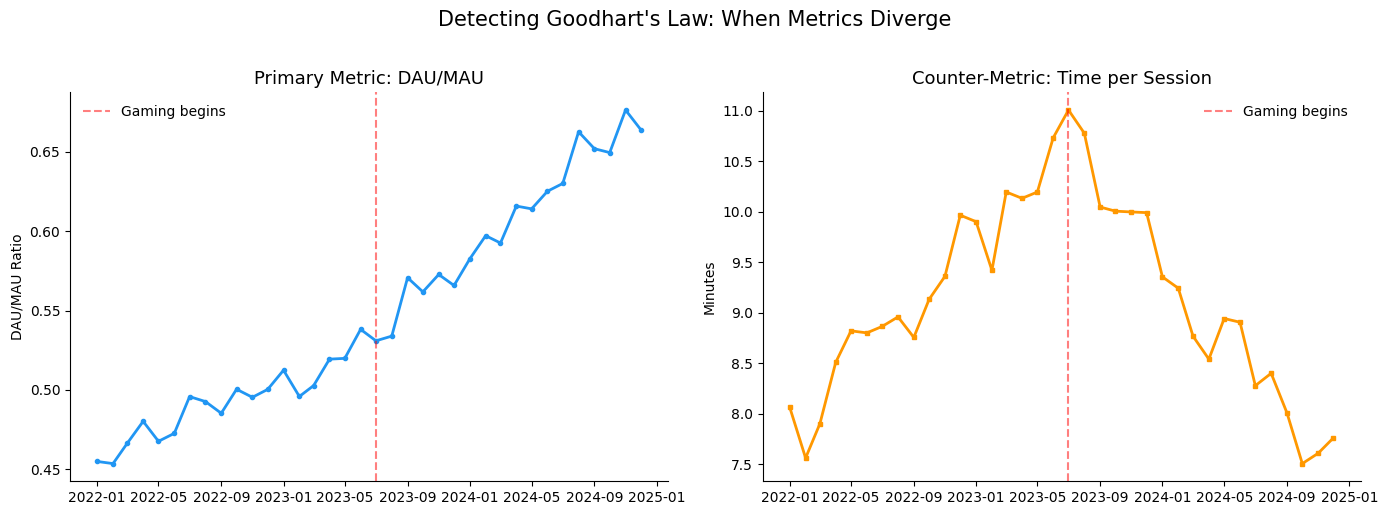

In [52]:
# -----------------------------------------------------------
# GUIDED — the dashboard
# Left panel: DAU/MAU over time (primary metric)
# Right panel: Time per session over time (counter-metric)
# The vertical line marks month 18, when gaming began
# -----------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Primary metric
ax1.plot(kpi_data.index, kpi_data["DAU/MAU"], color="#2196F3",
         linewidth=2, marker="o", markersize=3)
ax1.axvline(x=dates[18], color="red", linestyle="--", alpha=0.5,
            label="Gaming begins")
ax1.set_title("Primary Metric: DAU/MAU", fontsize=13)
ax1.set_ylabel("DAU/MAU Ratio")
ax1.legend(frameon=False)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Counter-metric
ax2.plot(kpi_data.index, kpi_data["Time per Session (min)"],
         color="#FF9800", linewidth=2, marker="s", markersize=3)
ax2.axvline(x=dates[18], color="red", linestyle="--", alpha=0.5,
            label="Gaming begins")
ax2.set_title("Counter-Metric: Time per Session", fontsize=13)
ax2.set_ylabel("Minutes")
ax2.legend(frameon=False)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.suptitle("Detecting Goodhart's Law: When Metrics Diverge", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [53]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Measure the divergence
# Two blanks. The chart shows it; a monitoring system needs a number.
# -----------------------------------------------------------

# Correlation between DAU/MAU and time per session, within each phase.
# Months 0-17 are the organic phase; months 18-35 are the gaming phase.
corr_organic = kpi_data.iloc[:18]["DAU/MAU"].corr(
    kpi_data.iloc[:18]["Time per Session (min)"]
)

corr_gaming = kpi_data.iloc[18:]["DAU/MAU"].corr(
    kpi_data.iloc[18:]["Time per Session (min)"]
)

print(f"Correlation (organic phase): {corr_organic:+.2f}")
print(f"Correlation (gaming phase):  {corr_gaming:+.2f}")
if corr_organic > 0 and corr_gaming < 0:
    print("\nSign flip = Goodhart's Law detected!")

Correlation (organic phase): +0.93
Correlation (gaming phase):  -0.96

Sign flip = Goodhart's Law detected!


### Interpretation Question

**Q1:** In the organic phase, DAU/MAU and time-per-session are positively correlated. In the gaming phase, they become negatively correlated. Explain why this sign flip is a diagnostic signal for Goodhart's Law.

**Q2:** You are a product economist at this company. The VP of Growth shows the DAU/MAU chart (left panel only) and says, "Engagement is up 30% — great quarter!" What would you say?

*Your answers here:*

Q1: in the organic phase, the more users that return regularly, the more time they spend per session. in the gaming phase, the negative correlation of DAU/MAU rising while session time falls is a signal that the company may be improving its engagement through notifications rather than through quality user visits.

Q2: even though DAU/MAU is up, this may be through other means that are not quality engagement. if DAU/MAU is rising while time per session is falling, it is possible this is from notifications causing sporadic opening and closing of the app. we should check if users are opening the app more often for shorter periods, and check retention before deciding if this is a genuine improvement in engagement.



## Part 4: Write a Verification Module (PRODUCTION — 10 min)

Save your fixed `deflate_series()` function as a standalone Python module that can be imported in future labs.

Copy the **body** of your `deflate_series_fixed` from Part 1 into the module
below, keeping the docstring and the guard clauses that are already there.

**Also carry Lab 1 forward.** Paste the `profile_dataframe()` you wrote in
Lab 1 Part 3 into the same file, so `deflation_utils.py` holds both. It is the
function you will reach for first on every new dataset this term, and a module
you can `import` is a portfolio artifact in a way a notebook cell is not.
Give it the same docstring treatment as `deflate_series()`.

The verification at the bottom reuses Part 1's `check_deflated`, so the module
is tested against the definition of a base-year deflation, not against your own
earlier output.

In [54]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Write deflation_utils.py
# -----------------------------------------------------------
module_code = '''
\"\"\"Deflation utilities for ECON 5200 labs.\"\"\"

import pandas as pd


def deflate_series(nominal, cpi, base_year=2020):
    \"\"\"Convert a nominal time series to real (constant-dollar) values.

    Parameters
    ----------
    nominal : pd.Series
        Nominal values indexed by date.
    cpi : pd.Series
        CPI values indexed by date, at the SAME frequency and with the SAME
        seasonal adjustment as `nominal`.
    base_year : int
        Year whose dollars to express values in. The base is that year's
        average CPI.

    Returns
    -------
    pd.Series
        Real values in base_year dollars, on the dates both inputs share,
        with no missing values.

    Raises
    ------
    ValueError
        If base_year is not present in the CPI index, or if the two series
        share no dates.
    \"\"\"
    if not (cpi.index.year == base_year).any():
        raise ValueError(f"Base year {base_year} not found in CPI data.")

    # YOUR CODE HERE — the body of your deflate_series_fixed from Part 1
    base = cpi.loc[cpi.index.year == base_year]
    if len(base) == 0:
      raise ValueError(f"base_year {base_year} not present in the CPI Index")

    date = nominal.index.intersection(cpi.index)
    nominal = nominal.loc[date]
    cpi = cpi.loc[date]

    real = (nominal / cpi) * base.mean()

    return real.dropna()

# YOUR CODE HERE — paste profile_dataframe() from Lab 1 Part 3

def profile_dataframe(data, unit_col="name", time_col="date"):
    """Return a dict describing the structure and completeness of `data`."""
    profile = {}
    profile["shape"] = data.shape

    # 1. How many units, and how many periods?                    [Step 0c]
    profile["n_units"]   = data[unit_col].nunique()
    profile["n_periods"] = data[time_col].nunique()

    # The taxonomy follows from those two counts. Read this; it is the
    # whole point of the chapter.
    if profile["n_units"] > 1 and profile["n_periods"] > 1:
        profile["structure"] = "panel"
    elif profile["n_periods"] > 1:
        profile["structure"] = "time series"
    else:
        profile["structure"] = "cross-sectional"

    # 2. Count the periods each unit actually appears in.         [Step 0c]
    periods_per_unit = data.groupby(unit_col)[time_col].nunique()

    # 3. Keep only the units that appear in every period, and say whether
    #    that is all of them.                                     [Step 0c]
    complete = periods_per_unit[periods_per_unit == profile["n_periods"]]
    profile["complete_units"] = len(complete)
    profile["balanced"] = len(complete) == profile["n_units"]

    # 4. The share of each column that is missing, as a percentage.
    #    One entry per column, built with the loop.               [Step 0d]
    missing = {}
    for col in data.columns:
        missing[col] = data[col].isna().mean() * 100
    profile["missing"] = missing

    return profile

'''

"""Convert a nominal time series to constant base_year dollars.

    Returns a Series with no missing values, indexed by the dates on which
    BOTH inputs are observed.
    """
    # YOUR CODE HERE — one fix for every bug you documented above


with open("deflation_utils.py", "w") as f:
    f.write(module_code.strip())

print("deflation_utils.py saved!")
print("\nVerification test:")

import importlib
import deflation_utils
importlib.reload(deflation_utils)

check_deflated(deflation_utils.deflate_series(wages, cpi_data, base_year=2020),
               wages, cpi_data, base_year=2020)
print("Module passes the Part 1 check.")

deflation_utils.py saved!

Verification test:
Module passes the Part 1 check.


---
## AI-Assisted Expansion: Index-Integrity Monitor

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over debugging a deflation pipeline, measuring substitution bias in the right units, and detecting a Goodhart sign flip. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task
Build ONE interactive monitor, inside this notebook (ipywidgets + plotly), that lets the user:
1. Pick a start date and see the CPI-U vs C-CPI-U gap recomputed in **both** index points per year and percentage points per year
2. Switch between the seasonally adjusted and unadjusted CPI-U and see why the gap moves
3. Set a rolling-window length and watch the rolling correlation between DAU/MAU and time per session
4. Get an alert on the first window where that correlation turns negative

Use the functions you already built; do not write a second module.

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [55]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python data scientist specializing
# in price-index measurement and KPI monitoring.
#
# [Request] I just completed a diagnosis-first lab where I fixed
# a four-bug deflation function (deflate_series_fixed), measured
# the CPI-U vs C-CPI-U substitution bias as a difference of
# annual inflation rates in percentage points per year, and
# detected a Goodhart sign flip between DAU/MAU and time per
# session. Build ONE interactive monitor that runs in Colab:
#   1. a start-date picker that recomputes the CPI-U vs C-CPI-U
#      gap as index points per year AND as pp per year
#   2. a toggle between CPIAUCNS and CPIAUCSL for CPI-U
#   3. a rolling-window slider for the correlation between the
#      two columns of kpi_data
#   4. an alert naming the first window where it turns negative
#
# [Iterate] Use ipywidgets, plotly and pandas. Reuse my names:
# load_fred, cpi_u, cpi_c, combined_norm, kpi_data,
# deflation_utils.deflate_series. No Streamlit, no new .py file.
#
# [Mechanism Check] Add inline comments explaining:
#   - why index points per year is not a rate, and how the pp
#     figure is computed from compounding
#   - why C-CPI-U must be compared with the unadjusted CPI-U
#   - how the rolling window trades detection speed for noise
#
# [Evaluate] Explain which Boskin component the gap measures,
# and what a monitoring team should do when the alert fires.

# PASTE AI-GENERATED CODE BELOW:

import pandas as pd
import ipywidgets as widgets
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, clear_output

# Reuse your existing unadjusted CPI-U and chained CPI.
cpi_u_nsa = cpi_u
cpi_u_sa = load_fred("CPIAUCSL", observation_start="1999-12-01")

# Offer start months available in all three series, so changing the
# CPI-U toggle does not invalidate the selected date.
start_dates = (
    cpi_u_nsa.index
    .intersection(cpi_u_sa.index)
    .intersection(cpi_c.index)
    .sort_values()
)
start_dates = start_dates[:-1]  # Leave at least one later month.

start_picker = widgets.Dropdown(
    options=[(date.strftime("%b %Y"), date) for date in start_dates],
    value=start_dates[0],
    description="Start date:",
    layout=widgets.Layout(width="250px"),
)

cpi_toggle = widgets.ToggleButtons(
    options=[
        ("Unadjusted: CPIAUCNS", "CPIAUCNS"),
        ("Adjusted: CPIAUCSL", "CPIAUCSL"),
    ],
    description="CPI-U:",
)

window_slider = widgets.IntSlider(
    value=6, min=3, max=18, step=1,
    description="Window:",
    continuous_update=False,
    readout_format="d",
)
output = widgets.Output()


def update_monitor(change=None):
    with output:
        clear_output(wait=True)

        selected_cpi = (
            cpi_u_nsa if cpi_toggle.value == "CPIAUCNS" else cpi_u_sa
        )

        # Match months before normalizing. Both indexes start at 100
        # in the month selected by the user.
        combined = pd.DataFrame({
            "CPI-U": selected_cpi,
            "C-CPI-U": cpi_c,
        }).loc[start_picker.value:].dropna()

        if len(combined) < 2:
            print("Choose an earlier start date to compare two months.")
            return

        combined_norm = combined / combined.iloc[0] * 100
        years = (
            combined_norm.index[-1] - combined_norm.index[0]
        ).days / 365.25

        end_u = combined_norm["CPI-U"].iloc[-1]
        end_c = combined_norm["C-CPI-U"].iloc[-1]
        gap_points_year = (end_u - end_c) / years

        rate_u = 100 * ((end_u / 100) ** (1 / years) - 1)
        rate_c = 100 * ((end_c / 100) ** (1 / years) - 1)
        gap_pp_year = rate_u - rate_c

        print(
            f"{combined_norm.index[0]:%b %Y} to "
            f"{combined_norm.index[-1]:%b %Y} ({years:.1f} years)"
        )
        print(f"Index gap: {gap_points_year:.2f} index points per year")
        print(f"Inflation-rate gap: {gap_pp_year:.2f} pp per year")

        # Index points per year divides a difference in index LEVELS by
        # time; it is not an inflation rate. The pp figure subtracts
        # the two compounded annual percentage growth rates above.
        if cpi_toggle.value == "CPIAUCSL":
            print(
                "Comparison caution: C-CPI-U is unadjusted, while "
                "CPIAUCSL is seasonally adjusted. Their monthly "
                "endpoints are not directly like for like."
            )
        # For the main estimate, compare unadjusted C-CPI-U with
        # unadjusted CPIAUCNS so seasonal adjustment does not affect
        # the measured endpoint gap.

        fig_cpi = go.Figure()
        for column in combined_norm.columns:
            fig_cpi.add_trace(go.Scatter(
                x=combined_norm.index,
                y=combined_norm[column],
                mode="lines",
                name=column,
            ))
        fig_cpi.update_layout(
            title="CPI comparison",
            xaxis_title="Month",
            yaxis_title=f"Index ({combined_norm.index[0]:%b %Y} = 100)",
            height=360,
        )
        fig_cpi.show()

        window = window_slider.value
        rolling_corr = (
            kpi_data["DAU/MAU"]
            .rolling(window=window, min_periods=window)
            .corr(kpi_data["Time per Session (min)"])
        )
        negative = rolling_corr[rolling_corr < 0]

        if negative.empty:
            print(f"No negative {window}-month correlation found.")
        else:
            first_end = negative.index[0]
            first_position = kpi_data.index.get_loc(first_end)
            first_start = kpi_data.index[first_position - window + 1]
            print(
                f"ALERT: First negative {window}-month window: "
                f"{first_start:%b %Y}–{first_end:%b %Y} "
                f"(correlation {negative.iloc[0]:+.2f})."
            )

        # Shorter windows can alert sooner but react more to noise;
        # longer windows are steadier but detect a change later.
        fig_kpi = make_subplots(specs=[[{"secondary_y": True}]])
        fig_kpi.add_trace(
            go.Scatter(
                x=kpi_data.index, y=kpi_data["DAU/MAU"],
                name="DAU/MAU", mode="lines+markers",
            ),
            secondary_y=False,
        )
        fig_kpi.add_trace(
            go.Scatter(
                x=kpi_data.index,
                y=kpi_data["Time per Session (min)"],
                name="Time per session", mode="lines+markers",
            ),
            secondary_y=True,
        )
        fig_kpi.update_layout(
            title=f"Engagement and quality ({window}-month rolling correlation)",
            height=420,
        )
        fig_kpi.update_yaxes(title_text="DAU/MAU", secondary_y=False)
        fig_kpi.update_yaxes(
            title_text="Minutes per session", secondary_y=True
        )
        fig_kpi.show()

        fig_corr = go.Figure(go.Scatter(
            x=rolling_corr.index,
            y=rolling_corr,
            mode="lines+markers",
            name="Rolling correlation",
        ))
        fig_corr.add_hline(y=0, line_dash="dash", line_color="red")
        fig_corr.update_layout(
            title="Rolling correlation: DAU/MAU vs. time per session",
            xaxis_title="Window ending month",
            yaxis_title="Correlation",
            yaxis_range=[-1.05, 1.05],
            height=320,
        )
        fig_corr.show()


for control in (start_picker, cpi_toggle, window_slider):
    control.observe(update_monitor, names="value")

display(
    widgets.VBox([
        widgets.HBox([start_picker, cpi_toggle]),
        window_slider,
        output,
    ])
)
update_monitor()


### Document the interaction

Three short answers. This is what is graded for the expansion, not the code.

1. **What did the AI get wrong or leave out?** Name one line you had to change,
   or one claim in its explanation that your own output contradicts.
2. **How did you verify it?** Point to a number the dashboard shows that you
   also computed by hand earlier in this lab, and say whether they match.
3. **What would you ask differently next time?**

*Your answers here:*

1. the ai left out the deflation_utils.deflate_series even though it was supposed to reuse that function. the dashboard also compares price indexes and kpis but doesnt call the deflation module.

2. it was verified with CPIAUNS and the start date at december 1999 matches the inflation rate gap of 0.27 percentage points per year that i previously had calculated as well.

3. i would be more specific in my request by pointing to which functions should be used and where; also i would ask the AI to check itself against the outputs that i had calculated and self correct.

---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.** Replace every `[YOUR VALUE]` with the number from your own output before you paste it.

In [56]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Diagnosed and fixed four bugs in a deflation pipeline, including
#   output in 1982-84 dollars mislabelled as 2020 dollars
# * Measured upper-level substitution bias: CPI-U [YOUR VALUE]% a year vs
#   C-CPI-U [YOUR VALUE]% a year = [YOUR VALUE] pp per year, and explained
#   why the [YOUR VALUE] index-point gap per year is not that number
# * Detected Goodhart's Law as a correlation flip from [YOUR VALUE] to
#   [YOUR VALUE] between DAU/MAU and time per session
# * Shipped deflation_utils.py with a tested deflate_series()
# * Built an interactive index-integrity monitor
#
# **Please write a README.md entry including:**
# 1. Project Title: Index Integrity — Deflation, Substitution Bias & Goodhart
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional applied econometrician wrote it."

---

## Submit this lab on GitHub

**Repository name for this lab:** `econ5200-lab02-deflation`

**First time?** Read the **GitHub Setup and Repository Guide** page in the Start Here module once,
start to finish. It assumes you have never used git and never seen GitHub.

1. On [github.com](https://github.com): **+** (top right) → **New repository**.
   Name it exactly `econ5200-lab02-deflation`, tick **Add a README file**, and create it.
2. In Colab: **File → Save a copy in GitHub**. Choose `econ5200-lab02-deflation`, branch `main`,
   commit message `Lab 02 submission`. This pushes the notebook, and the
   notebook's rendered output — charts included — is what is graded.
3. Open the repo on github.com, click `README.md`, then the pencil icon, and
   paste in the README you drafted from the README prompt above. **Commit
   changes.** Check every number in it against your own output first: this
   goes out under your name.
4. `deflation_utils.py` is **not** pushed by step 2 — that step sends the
   notebook only, and the file lives in Colab's temporary storage, which is
   wiped when the session ends. Download it first: in the Colab **Files** panel
   (folder icon, left), right-click `deflation_utils.py` → **Download**. Then on
   the repo page use **Add file → Upload files**, drag it in, and **Commit
   changes**. It is part of what is graded.
5. On Canvas: in Colab use **File → Download → Download .ipynb**, upload that
   file to the assignment, and paste your repository URL in the **Comments**
   box beside the upload. Then click **Submit**. Do not use the Website URL
   tab: Canvas keeps one submission, so a URL sent on its own replaces your
   notebook.

No terminal, no token, nothing to install.

---

**Lab 2 complete!** You've debugged a deflation pipeline, quantified substitution bias empirically, built a Goodhart detection dashboard, and produced a reusable Python module. These skills transfer directly to any monetary data analysis or KPI monitoring role.